In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

c:\Users\Srimanth\Desktop\knoweledge_graph\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 22.0k/22.0k [00:00<00:00, 6.44MB/s]

Extracting files...
Path to dataset files: C:\Users\Srimanth\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Srimanth\Desktop\Titanic-Dataset.csv")
df.head(5)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#survived is target column
#passenger id can be droped
#Name can be dropped
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
#i can see some of the cols are having the missing values like age,cabin,embarked
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
#from the above i can see that survived % is 38%
#and 50 % of the people travelled in 3rd class
#avg age is 29 of the all passengers
#75% of the  has atleast 1 child/spouse
# 50 % of the people are with no parents/children
#

In [6]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

we can see the data is imbalanced

<Axes: xlabel='Survived', ylabel='count'>

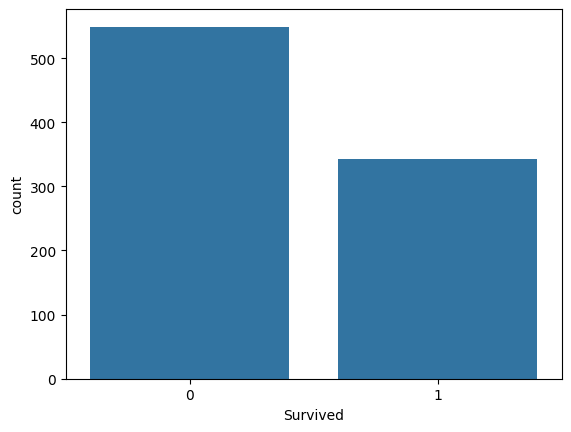

In [7]:
sns.countplot(data=df,x='Survived')

In [8]:
df.duplicated().sum()
#no duplicates


np.int64(0)

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

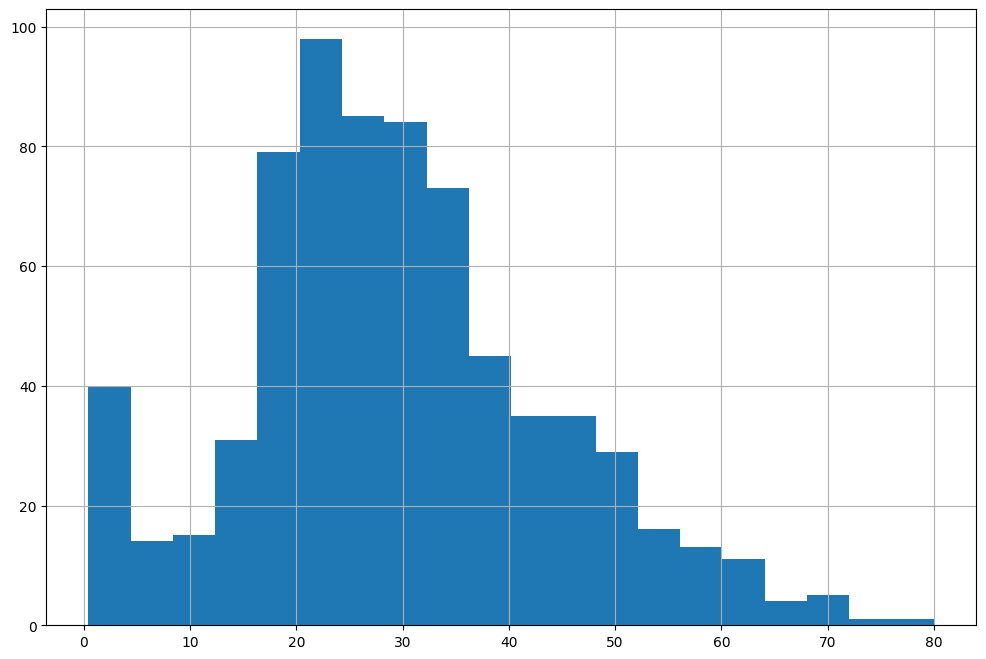

In [10]:
#we have found the missing values in AGE,CABIN
import matplotlib.pyplot as plt
import seaborn as  sns
plt.figure(figsize=(12,8))
df['Age'].hist(bins=20)
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

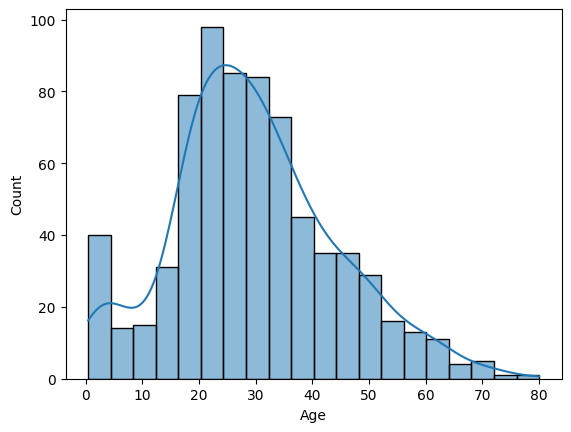

In [11]:
sns.histplot(data=df,x='Age',kde=True)

In [12]:
df['Cabin'].isnull().sum()/len(df)*100


np.float64(77.10437710437711)

In [13]:
#we can see AGE follws normal distribution we can use the mean to fill the missing values
#we can see the cabin column is 77% is missing so we cannot drop or impute we can extract the first letter of the cabin which indicate the deck and m for missing
df['Age']=df["Age"].fillna(df['Age'].mean())
df['Deck']=df['Cabin'].apply(lambda x:x[0] if pd.notnull(x) else 'M')

In [14]:
df.drop(columns=['Cabin'],inplace=True)

In [15]:
pd.crosstab(df['Survived'],df['Deck'],normalize='index')*100

Deck,A,B,C,D,E,F,G,M,T
Survived,,,,,,,,,
0,1.457195,2.185792,4.371585,1.457195,1.457195,0.910747,0.364299,87.613843,0.182149
1,2.046784,10.233918,10.233918,7.309942,7.017544,2.339181,0.584795,60.233918,0.000000


from the above can see that 87% of people from Deck'M' probably lower deck is not survived and the above decks which have survived Rate

In [16]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,M
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,M
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,M


In [17]:
pd.crosstab(df['Survived'],df['Pclass'],normalize='index')*100

Pclass,1,2,3
Survived,,,
0,14.571949,17.668488,67.759563
1,39.766082,25.438596,34.795322


this Pclass suported the above results that deck which lower class like '3' have low survival chancs while higher class have more chance of surviaval may be due to the avaliability of life boats

we can see the columns 'SibSp' and 'Parch' is 'siblings,parents whcih can be comnined to get total family size

In [18]:
df['Family_Size']=df['SibSp']+df['Parch']+1
#+1 bacause the person alone travelled

In [19]:
df['Is_alone']=df['Family_Size'].apply(lambda x:1 if x==1 else 0)

In [20]:
pd.crosstab(df['Survived'],df['Is_alone'],normalize='index')*100

Is_alone,0,1
Survived,,
0,31.876138,68.123862
1,52.339181,47.660819


In [21]:
numeric_cols=df.select_dtypes(include='number').columns.to_list()
numeric_cols.remove('PassengerId')

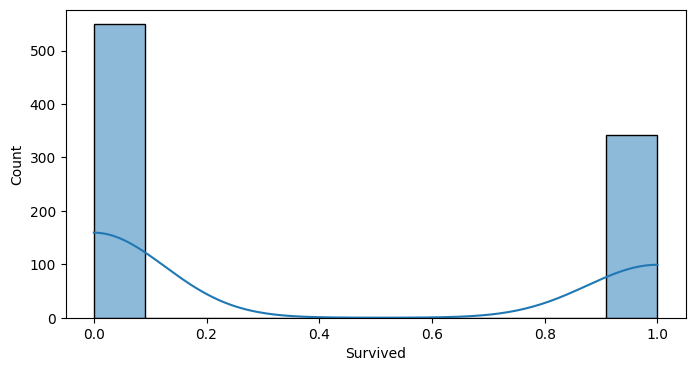

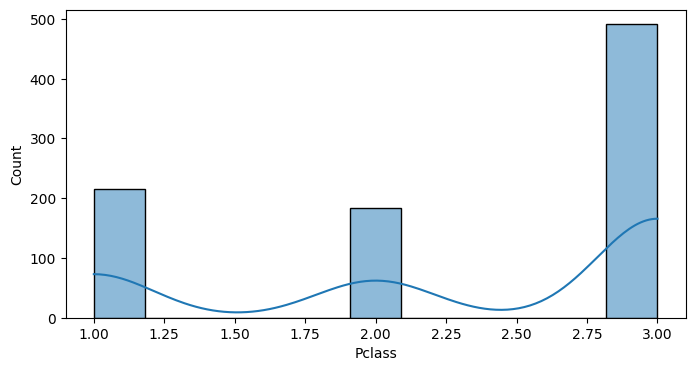

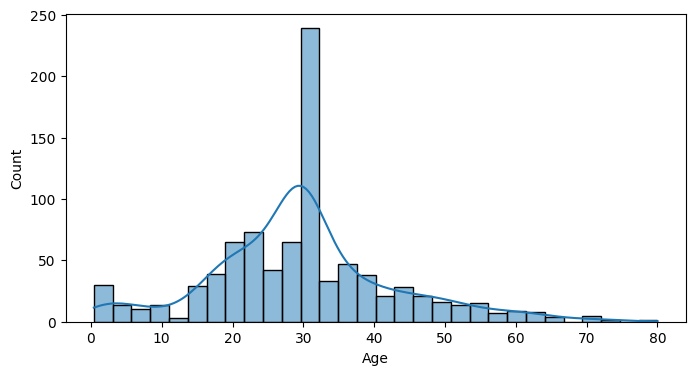

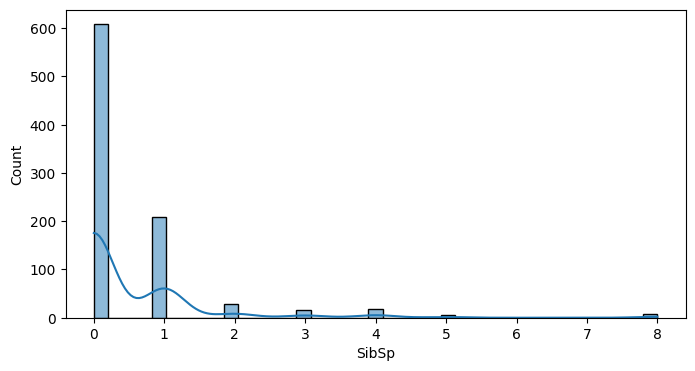

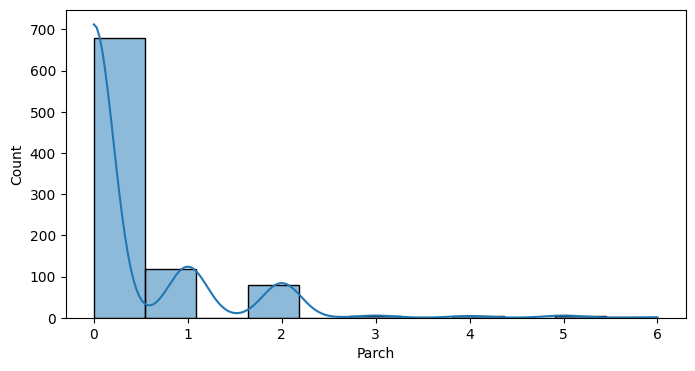

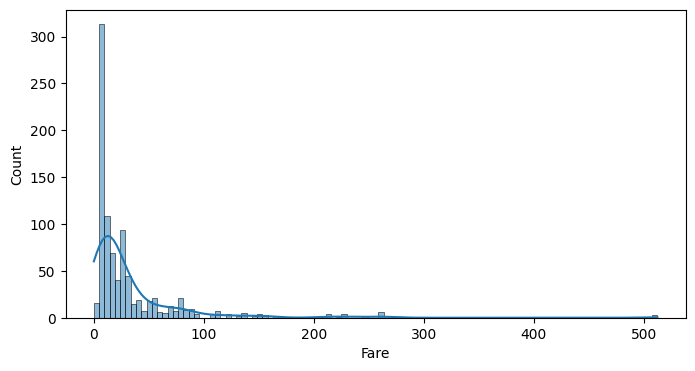

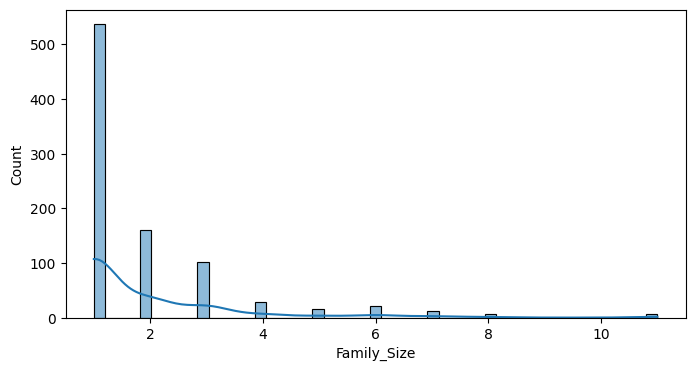

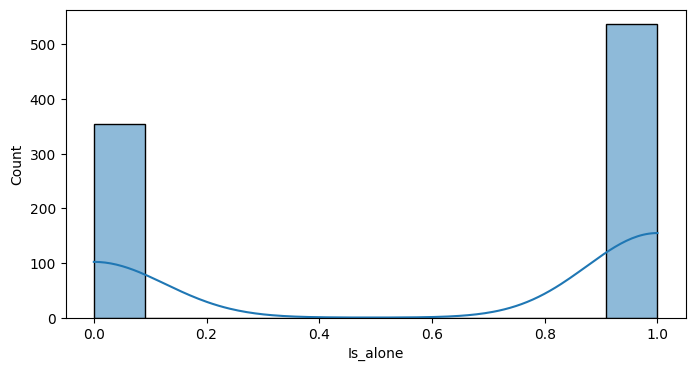

In [22]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df,x=col,kde=True)
    plt.show()

<Axes: xlabel='Fare', ylabel='Count'>

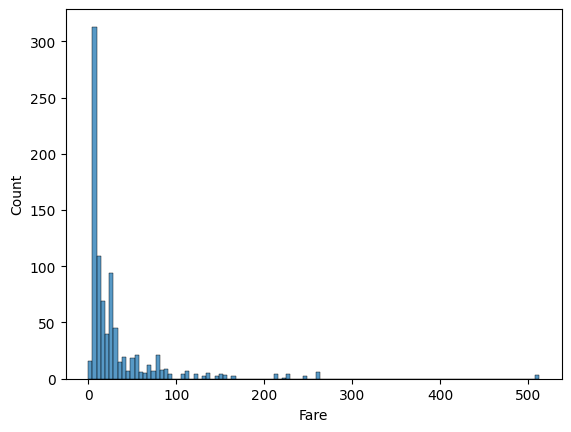

In [23]:
sns.histplot(data=df,x='Fare')

In [24]:
df['Fare_Bin']=pd.qcut(df['Fare'], 4, labels=[1, 2, 3, 4])

In [25]:
#i can see the Fare column is right skewed i will use the lo g transformation ti pull the distance vaues near

import numpy as np
df['Fare']=df['Fare'].apply(np.log1p)

<Axes: >

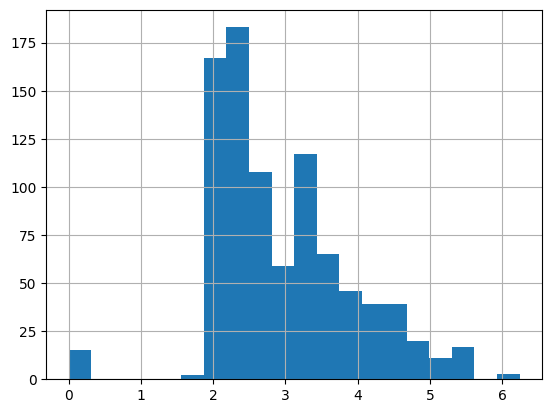

In [26]:
df['Fare'].hist(bins=20)

In [27]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Deck', 'Family_Size',
       'Is_alone', 'Fare_Bin'],
      dtype='object')

In [28]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Family_Size,Is_alone,Fare_Bin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,2.110213,S,M,2,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.280593,C,C,2,0,4
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.188856,S,M,1,1,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.990834,S,C,2,0,4
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.202765,S,M,1,1,2


In [29]:

from sklearn.model_selection import train_test_split
x=df.drop(columns=['PassengerId','Survived','Name','Ticket'])
y=df['Survived']

In [30]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Family_Size,Is_alone,Fare_Bin
0,3,male,22.000000,1,0,2.110213,S,M,2,0,1
1,1,female,38.000000,1,0,4.280593,C,C,2,0,4
2,3,female,26.000000,0,0,2.188856,S,M,1,1,2
3,1,female,35.000000,1,0,3.990834,S,C,2,0,4
4,3,male,35.000000,0,0,2.202765,S,M,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.000000,0,0,2.639057,S,M,1,1,2
887,1,female,19.000000,0,0,3.433987,S,B,1,1,3
888,3,female,29.699118,1,2,3.196630,S,M,4,0,3
889,1,male,26.000000,0,0,3.433987,C,C,1,1,3


In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [32]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Family_Size,Is_alone,Fare_Bin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,2.110213,S,M,2,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.280593,C,C,2,0,4
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.188856,S,M,1,1,2


In [33]:
df['Deck'].value_counts()

Deck
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [34]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [35]:
#Encoding the categorical values
#sex
df['Sex']=df['Sex'].map({'male':0,'female':1})

In [36]:
# Fill missing Embarked values with the most common port ('S')
x_train['Embarked'] = x_train['Embarked'].fillna('S')
x_test['Embarked'] = x_test['Embarked'].fillna('S')


In [37]:
#doing the encoding for at once using column tranfer
import pandas as pd
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer

#the deck has the order like top is different from deck so we us  the ordial encoding for this we need to first put them in the order
deck_order=['M', 'G', 'F', 'E', 'D', 'C', 'B', 'A', 'T']

preprocessor=ColumnTransformer(
    transformers=[
        ('ohe',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),['Sex','Embarked']),
        ('ordinal',OrdinalEncoder(categories=[deck_order],
                                  handle_unknown='use_encoded_value',
                                  unknown_value=-1
                                  ),['Deck'])      
    ],
    remainder='passthrough'
)

In [38]:
x_train_transformed=preprocessor.fit_transform(x_train)
x_test_transformed=preprocessor.transform(x_test)

In [39]:
x_cols=preprocessor.get_feature_names_out()

In [40]:
x_cols


array(['ohe__Sex_male', 'ohe__Embarked_Q', 'ohe__Embarked_S',
       'ordinal__Deck', 'remainder__Pclass', 'remainder__Age',
       'remainder__SibSp', 'remainder__Parch', 'remainder__Fare',
       'remainder__Family_Size', 'remainder__Is_alone',
       'remainder__Fare_Bin'], dtype=object)

In [41]:
x_train_final=pd.DataFrame(x_train_transformed,columns=x_cols,index=x_train.index)
x_test_final=pd.DataFrame(x_test_transformed,columns=x_cols,index=x_test.index)

In [42]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()


x_train_scaled = pd.DataFrame(
    scaler.fit_transform(x_train_final), 
    columns=x_train_final.columns, 
    index=x_train_final.index
)

x_test_scaled = pd.DataFrame(
    scaler.transform(x_test_final), 
    columns=x_test_final.columns, 
    index=x_test_final.index
)


In [43]:
#lets try without smote because it is a baseline model
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()


In [44]:
logistic_model_without_smote=lr.fit(x_train_scaled,y_train)

In [45]:
logistic_model_without_smote_pred=logistic_model_without_smote.predict(x_test_scaled)

In [46]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,logistic_model_without_smote_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       110
           1       0.77      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [47]:
cm=confusion_matrix(y_test,logistic_model_without_smote_pred)

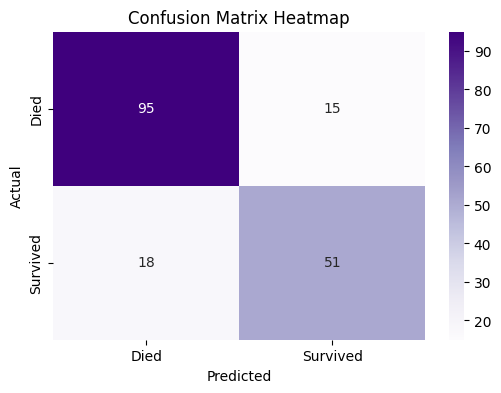

In [48]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Died', 'Survived'], 
            yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()


In [49]:
#let us use the smote data on the x_train and x_test to predict
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_res,y_train_res=smote.fit_resample(x_train_scaled,y_train)


In [50]:
x_train_res,y_train_res=smote.fit_resample(x_train_scaled,y_train)
logistic_model_smote=lr.fit(x_train_res,y_train_res)

In [51]:
logistic_model_smote_pred=logistic_model_smote.predict(x_test_scaled)

In [52]:
print(classification_report(logistic_model_smote_pred,y_test))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       104
           1       0.77      0.71      0.74        75

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [53]:
#this is withut smote accuracy is better because our dataset is not that imbalace 60-40 we shuld use the smote for extremely imbalance

In [54]:
from sklearn.metrics import roc_auc_score,roc_curve
y_probs = logistic_model_without_smote.predict_proba(x_test_scaled)[:, 1]


In [55]:
tpr,fpr,threshold=roc_curve(y_test,y_probs)
auc_score=roc_auc_score(y_test,y_probs)

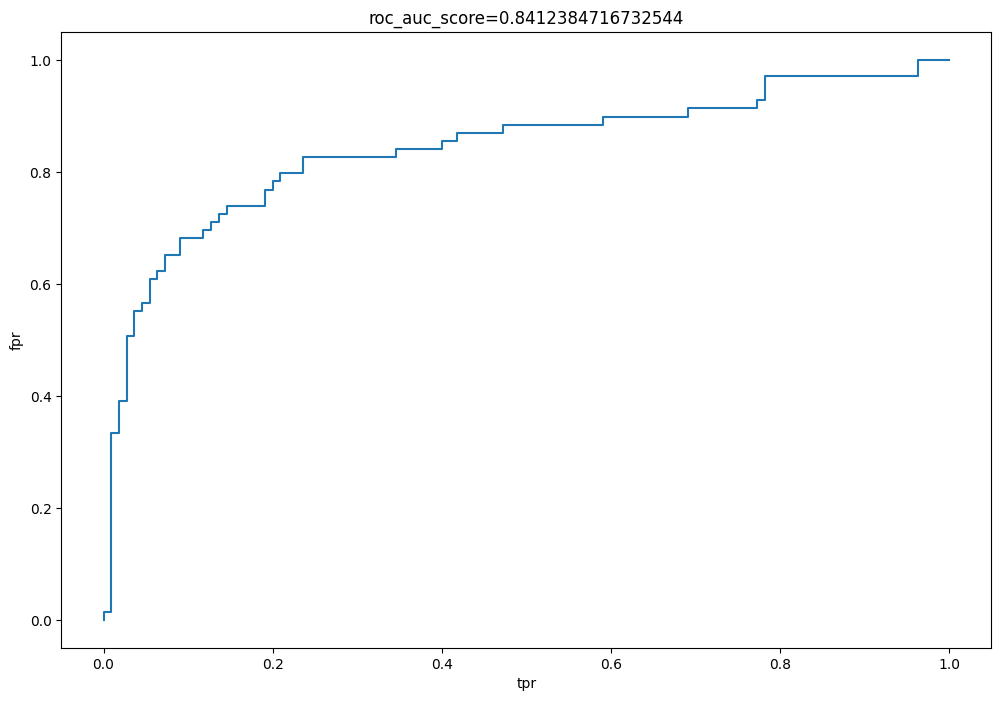

In [56]:
plt.figure(figsize=(12,8))
plt.plot(tpr,fpr)
plt.xlabel("tpr")
plt.ylabel("fpr")
plt.title(f"roc_auc_score={auc_score}")
plt.show()

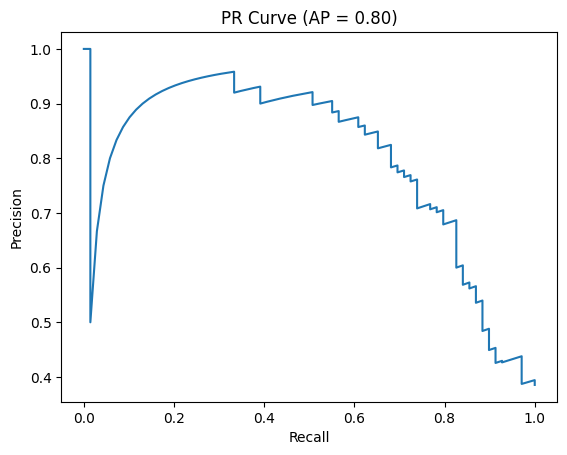

In [57]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (AP = {ap_score:.2f})")
plt.show()

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier,
                              AdaBoostClassifier,
                              ExtraTreesClassifier)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, auc,
                              precision_recall_curve, f1_score,
                              accuracy_score, precision_score, recall_score,
                              matthews_corrcoef, cohen_kappa_score)

In [59]:
models={
    "DecisionTree":DecisionTreeClassifier(random_state=42,max_depth=10),
    "GradientBoosting":GradientBoostingClassifier(random_state=42,n_estimators=100),
    "RandomForest":RandomForestClassifier(random_state=42,n_estimators=100,n_jobs=-1),
    "XGBoost":XGBClassifier(random_state=42,n_estimators=100,eval_metric='logloss')
    
}

In [60]:
def evaluate_model(model,x_train,y_train,x_test,y_test,model_name):
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    y_pred_proba=model.predict_proba(x_test)[:,1]
    metrics={
        "model_name":model_name,
        "precision":precision_score(y_test,y_pred),
        "Recall":recall_score(y_test,y_pred),
        "F1 Score":f1_score(y_test,y_pred)
    }
    return y_pred,y_pred_proba,metrics,model

In [61]:
x_train_scaled['ohe__Sex_male'].info()

<class 'pandas.core.series.Series'>
Index: 712 entries, 692 to 507
Series name: ohe__Sex_male
Non-Null Count  Dtype  
--------------  -----  
712 non-null    float64
dtypes: float64(1)
memory usage: 11.1 KB


In [62]:
baseline_results=[]
for model_name,model in models.items():
    try:
        y_pred,y_probs,metrics,model=evaluate_model(model,x_train_scaled,y_train,x_test_scaled,y_test,model_name)
        baseline_results.append(metrics)
        print(f"precision:{metrics['precision']}")
        print(f"Recall:{metrics['Recall']}")
        print(f"F1 Score:{metrics['F1 Score']}")
        print(f"model:{metrics['model_name']}")
        print("____________________________________________")

    except Exception as e:
        print(e)

precision:0.7627118644067796
Recall:0.6521739130434783
F1 Score:0.703125
model:DecisionTree
____________________________________________
precision:0.7962962962962963
Recall:0.6231884057971014
F1 Score:0.6991869918699187
model:GradientBoosting
____________________________________________
precision:0.75
Recall:0.7391304347826086
F1 Score:0.7445255474452555
model:RandomForest
____________________________________________
precision:0.7164179104477612
Recall:0.6956521739130435
F1 Score:0.7058823529411765
model:XGBoost
____________________________________________


In [63]:
#hyperparameter tunuing

In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

In [65]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [66]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

In [67]:
param_grids = {

    "Logistic Regression": {
        "C":[0.01,0.1,1,10],
        "penalty":["l2"],
        "solver":["lbfgs"]
    },

    "Decision Tree":{
        "max_depth":[3,5,7,None],
        "min_samples_split":[2,5,10],
        "min_samples_leaf":[1,2,4]
    },

    "Random Forest":{
        "n_estimators":[100,200,300],
        "max_depth":[5,10,None],
        "min_samples_split":[2,5],
        "min_samples_leaf":[1,2]
    },

    "Gradient Boosting":{
        "n_estimators":[100,200],
        "learning_rate":[0.01,0.1],
        "max_depth":[3,5]
    },

    "AdaBoost":{
        "n_estimators":[50,100,200],
        "learning_rate":[0.01,0.1,1]
    }
}

In [68]:
best_models = {}

for name, model in models.items():

    print("Tuning:", name)

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    grid.fit(x_train_scaled, y_train)

    best_models[name] = grid.best_estimator_

    print("Best Parameters:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    print("-----------------------")

Tuning: Logistic Regression
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.8628818883717002
-----------------------
Tuning: Decision Tree
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Score: 0.8563496775487371
-----------------------
Tuning: Random Forest
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score: 0.8854034598862185
-----------------------
Tuning: Gradient Boosting
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV Score: 0.8849004807743052
-----------------------
Tuning: AdaBoost
Best Parameters: {'learning_rate': 1, 'n_estimators': 50}
Best CV Score: 0.8749205614135083
-----------------------


In [69]:
from sklearn.metrics import classification_report

for name, model in best_models.items():

    y_pred = model.predict(x_test_scaled)

    print("Model:", name)
    print(classification_report(y_test,y_pred))

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       110
           1       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179

Model: Decision Tree
              precision    recall  f1-score   support

           0       0.77      0.90      0.83       110
           1       0.78      0.57      0.66        69

    accuracy                           0.77       179
   macro avg       0.77      0.73      0.74       179
weighted avg       0.77      0.77      0.76       179

Model: Random Forest
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       110
           1       0.76      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.76       179
weigh

In [70]:
results = []

for name, model in best_models.items():

    y_pred = model.predict(x_test_scaled)
    y_prob = model.predict_proba(x_test_scaled)[:,1]

    auc = roc_auc_score(y_test, y_prob)

    results.append([name, auc])

df_results = pd.DataFrame(results, columns=["Model","ROC_AUC"])
print(df_results.sort_values(by="ROC_AUC",ascending=False))

                 Model   ROC_AUC
0  Logistic Regression  0.840975
2        Random Forest  0.837484
4             AdaBoost  0.823518
3    Gradient Boosting  0.798946
1        Decision Tree  0.796904


In [71]:
final_model = best_models["Logistic Regression"]

final_model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [73]:
# Use absolute values of coefficients to represent importance magnitude
importance = final_model.coef_[0]

feat_importance = pd.Series(
    importance,
    index=x_train_scaled.columns
).sort_values(ascending=False)

print(feat_importance)


remainder__Fare           0.349580
ohe__Embarked_Q           0.232630
remainder__Fare_Bin       0.196701
ordinal__Deck             0.120896
remainder__Parch          0.004769
remainder__Family_Size   -0.181992
remainder__SibSp         -0.186761
ohe__Embarked_S          -0.247485
remainder__Is_alone      -0.353328
remainder__Age           -0.446081
remainder__Pclass        -0.471553
ohe__Sex_male            -1.812119
dtype: float64


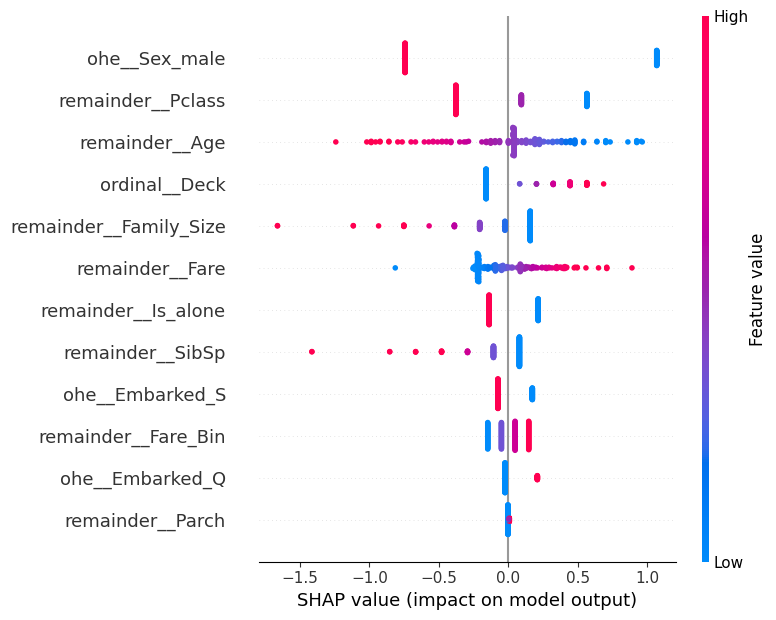

In [75]:
import shap

# 1. Initialize the explainer (it will automatically use LinearExplainer for LogisticRegression)
explainer = shap.Explainer(final_model, x_train_scaled)

# 2. Calculate SHAP values
# For binary classification, shap_values will often have two indices [class 0, class 1]
# We usually explain the positive class (index 1)
shap_test = explainer(x_test_scaled)

# 3. Plot the summary (using the positive class values)
shap.summary_plot(shap_test, x_test_scaled)


In [77]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("scaler", RobustScaler()),
    ("model", LogisticRegression())
])

In [78]:
import joblib

joblib.dump(final_model,"titanic_model.pkl")

['titanic_model.pkl']

In [79]:
model = joblib.load("titanic_model.pkl")

In [ ]:
new_passenger =pd.DataFrame({
    3,      # Pclass
    1,      # Sex
    22,     # Age
    1,      # SibSp
    0,      # Parch
    7.25,   # Fare
    0,      # Embarked_Q
    1,      # Embarked_S
    1,      # Family_Size
    1,      # Is_alone
    0,      # Title
    0       # Deck
})

In [83]:
prediction = final_model.predict(new_passenger)
prediction

c:\Users\Srimanth\Desktop\knoweledge_graph\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [84]:
import pandas as pd

new_passenger = pd.DataFrame({
    "Pclass":[3],
    "Sex":[1],
    "Age":[22],
    "SibSp":[1],
    "Parch":[0],
    "Fare":[7.25],
    "Family_Size":[2],
    "Is_alone":[0]
})